# Credit Card Fraud Detection
### Data Mining Policy Summary Project

**Science Question:**  
> *Can we accurately identify fraudulent credit card transactions using machine learning, and which transaction features are most predictive of fraud?*

**Dataset:** [Credit Card Fraud Detection Dataset](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud) — Kaggle / ULB Machine Learning Group  
**Technique:** Supervised Classification (Logistic Regression & Random Forest)

---

## Notebook Structure
1. [Setup & Data Loading](#1)
2. [Exploratory Data Analysis (EDA)](#2)
3. [Data Cleaning & Preprocessing](#3)
4. [Model Training](#4)
5. [Model Evaluation & Comparison](#5)
6. [Feature Importance Analysis](#6)
7. [Summary of Findings](#7)

---
## 1. Setup & Data Loading <a id='1'></a>

In [ ]:
# ── Core libraries ──────────────────────────────────────────────────────────
!pip install imbalanced-learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Machine learning ─────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score, ConfusionMatrixDisplay
)

# ── Class imbalance handling ─────────────────────────────────────────────────
from imblearn.over_sampling import SMOTE

# ── Plotting style ───────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print("All libraries loaded successfully.")

All libraries loaded successfully.


In [ ]:
# ── Load the dataset ─────────────────────────────────────────────────────────
# Download from: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
# Place 'creditcard.csv' in the same directory as this notebook.

df = pd.read_csv('creditcard.csv')

print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

Dataset shape: 284,807 rows × 31 columns


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
# ── Quick overview of data types and missing values ──────────────────────────
print("=== Data Types ===")
print(df.dtypes)
print("\n=== Missing Values ===")
print(df.isnull().sum())
print("\n=== Basic Statistics ===")
df.describe().round(3)

=== Data Types ===
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

=== Missing Values ===
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,...,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000
mean,94813.860,0.000,0.000,-0.000,0.000,0.000,0.000,-0.000,0.000,-0.000,...,0.000,-0.000,0.000,0.000,0.000,0.000,-0.000,-0.000,88.350,0.002
std,47488.146,1.959,1.651,1.516,1.416,1.380,1.332,1.237,1.194,1.099,...,0.735,0.726,0.624,0.606,0.521,0.482,0.404,0.330,250.120,0.042
min,0.000,-56.408,-72.716,-48.326,-5.683,-113.743,-26.161,-43.557,-73.217,-13.434,...,-34.830,-10.933,-44.808,-2.837,-10.295,-2.605,-22.566,-15.430,0.000,0.000
25%,54201.500,-0.920,-0.599,-0.890,-0.849,-0.692,-0.768,-0.554,-0.209,-0.643,...,-0.228,-0.542,-0.162,-0.355,-0.317,-0.327,-0.071,-0.053,5.600,0.000
50%,84692.000,0.018,0.065,0.180,-0.020,-0.054,-0.274,0.040,0.022,-0.051,...,-0.029,0.007,-0.011,0.041,0.017,-0.052,0.001,0.011,22.000,0.000
75%,139320.500,1.316,0.804,1.027,0.743,0.612,0.399,0.570,0.327,0.597,...,0.186,0.529,0.148,0.440,0.351,0.241,0.091,0.078,77.165,0.000
max,172792.000,2.455,22.058,9.383,16.875,34.802,73.302,120.589,20.007,15.595,...,27.203,10.503,22.528,4.585,7.520,3.517,31.612,33.848,25691.160,1.000


**Dataset notes:**  
- Features V1–V28 are principal components obtained via PCA (original features are confidential for privacy reasons).  
- `Time`: seconds elapsed since the first transaction.  
- `Amount`: transaction value in euros.  
- `Class`: target variable — **1 = Fraud**, **0 = Legitimate**.

---
## 2. Exploratory Data Analysis (EDA) <a id='2'></a>

=== Class Distribution ===
Legitimate transactions : 284,315 (99.83%)
Fraudulent transactions : 492 (0.17%)


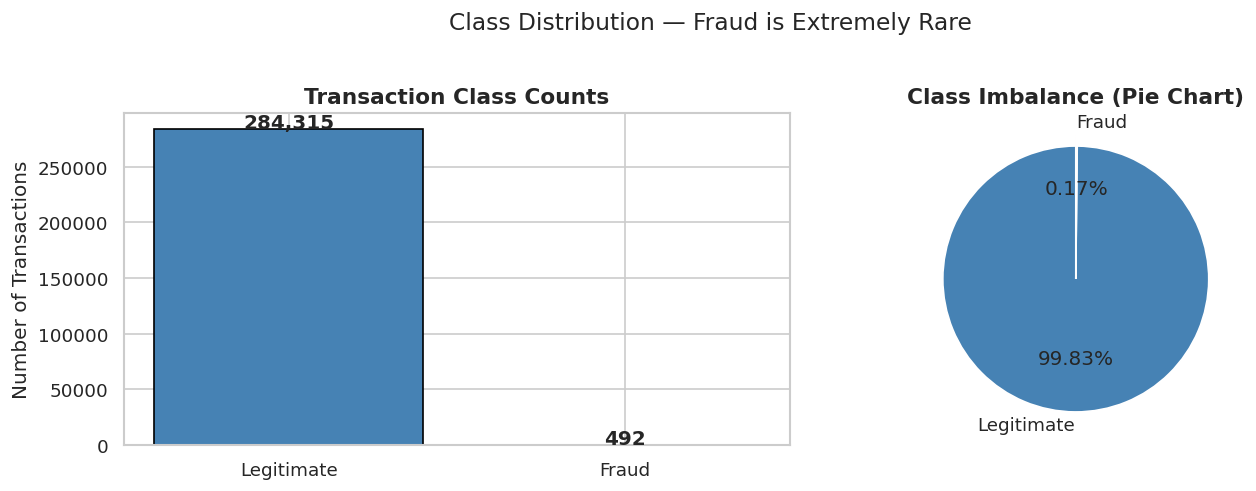

In [ ]:
# ── Class distribution ────────────────────────────────────────────────────────
# This is the most important initial check: how imbalanced is our dataset?

class_counts = df['Class'].value_counts()
fraud_pct = class_counts[1] / len(df) * 100

print("=== Class Distribution ===")
print(f"Legitimate transactions : {class_counts[0]:,} ({100 - fraud_pct:.2f}%)")
print(f"Fraudulent transactions : {class_counts[1]:,} ({fraud_pct:.2f}%)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(['Legitimate', 'Fraud'], class_counts.values, color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Transaction Class Counts', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Transactions')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

# Pie chart showing the imbalance clearly
axes[1].pie(class_counts.values, labels=['Legitimate', 'Fraud'],
            colors=['steelblue', 'tomato'], autopct='%1.2f%%',
            startangle=90, explode=(0, 0.08))
axes[1].set_title('Class Imbalance (Pie Chart)', fontsize=13, fontweight='bold')

plt.suptitle('Class Distribution — Fraud is Extremely Rare', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('fig1_class_distribution.png', bbox_inches='tight')
plt.show()

=== Transaction Amount Statistics ===
                          Legitimate      Fraud
Mean                           88.29     122.21
Median                         22.00       9.25
Max                         25691.16    2125.87


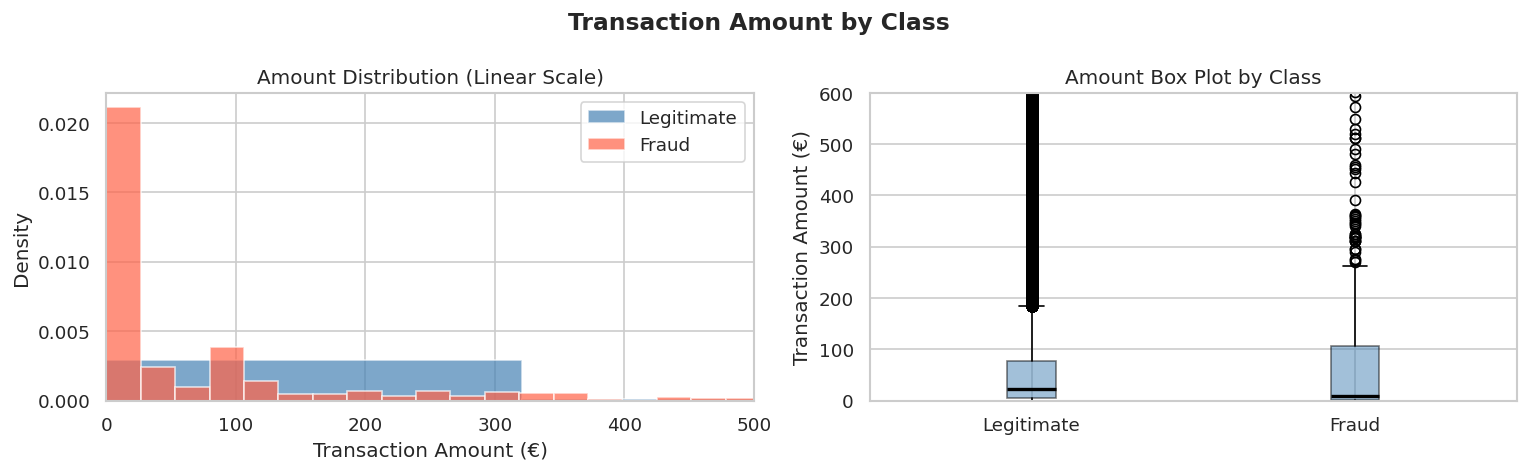

In [ ]:
# ── Transaction amount: fraud vs legitimate ───────────────────────────────────
# We want to understand if fraudulent transactions tend to be for different amounts.

fraud_amounts    = df[df['Class'] == 1]['Amount']
legit_amounts    = df[df['Class'] == 0]['Amount']

print("=== Transaction Amount Statistics ===")
print(f"{'':20s} {'Legitimate':>15s} {'Fraud':>10s}")
print(f"{'Mean':20s} {legit_amounts.mean():>15.2f} {fraud_amounts.mean():>10.2f}")
print(f"{'Median':20s} {legit_amounts.median():>15.2f} {fraud_amounts.median():>10.2f}")
print(f"{'Max':20s} {legit_amounts.max():>15.2f} {fraud_amounts.max():>10.2f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Log-scaled histogram to handle extreme range in amounts
axes[0].hist(legit_amounts, bins=80, color='steelblue', alpha=0.7, label='Legitimate', density=True)
axes[0].hist(fraud_amounts, bins=80, color='tomato', alpha=0.7, label='Fraud', density=True)
axes[0].set_xlabel('Transaction Amount (€)')
axes[0].set_ylabel('Density')
axes[0].set_title('Amount Distribution (Linear Scale)')
axes[0].legend()
axes[0].set_xlim(0, 500)

# Box plot for a cleaner comparison
axes[1].boxplot([legit_amounts, fraud_amounts], labels=['Legitimate', 'Fraud'],
                patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.5),
                medianprops=dict(color='black', linewidth=2))
axes[1].set_ylabel('Transaction Amount (€)')
axes[1].set_title('Amount Box Plot by Class')
axes[1].set_ylim(0, 600)

plt.suptitle('Transaction Amount by Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig2_amount_distribution.png', bbox_inches='tight')
plt.show()

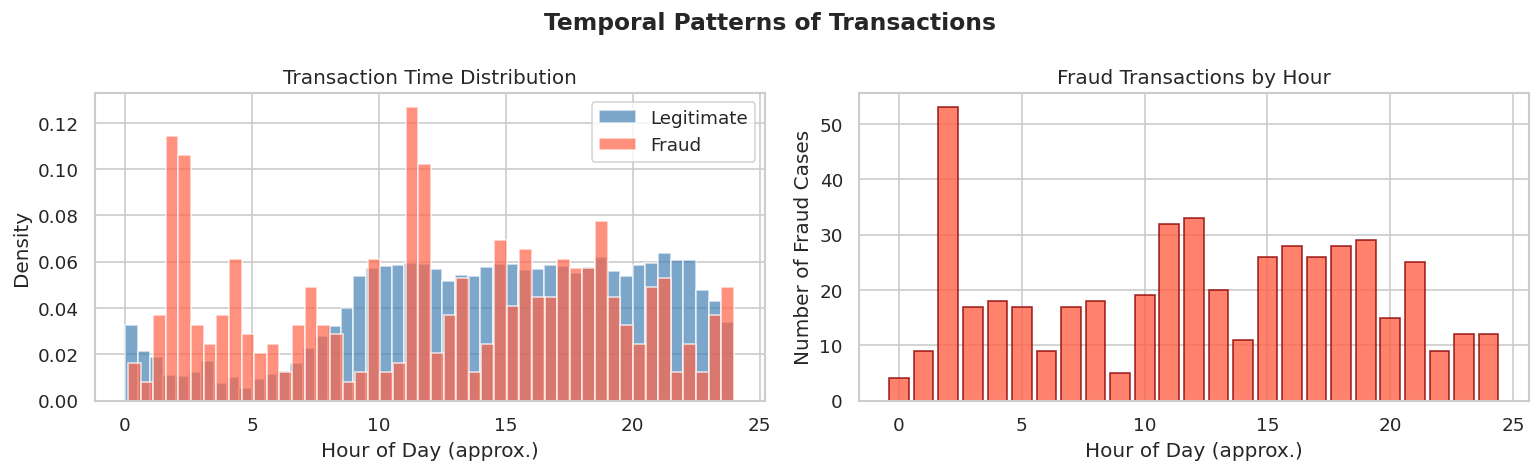

In [ ]:
# ── Transaction time: does fraud happen at specific times? ────────────────────
# 'Time' is seconds from the first transaction — we convert to hours for readability.

df['Hour'] = (df['Time'] / 3600) % 24  # approximate hour-of-day

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df[df['Class'] == 0]['Hour'], bins=48, color='steelblue', alpha=0.7, label='Legitimate', density=True)
axes[0].hist(df[df['Class'] == 1]['Hour'], bins=48, color='tomato', alpha=0.7, label='Fraud', density=True)
axes[0].set_xlabel('Hour of Day (approx.)')
axes[0].set_ylabel('Density')
axes[0].set_title('Transaction Time Distribution')
axes[0].legend()

# Fraudulent transactions per hour (absolute count)
fraud_by_hour = df[df['Class'] == 1]['Hour'].round().value_counts().sort_index()
axes[1].bar(fraud_by_hour.index, fraud_by_hour.values, color='tomato', edgecolor='darkred', alpha=0.8)
axes[1].set_xlabel('Hour of Day (approx.)')
axes[1].set_ylabel('Number of Fraud Cases')
axes[1].set_title('Fraud Transactions by Hour')

plt.suptitle('Temporal Patterns of Transactions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig3_time_distribution.png', bbox_inches='tight')
plt.show()

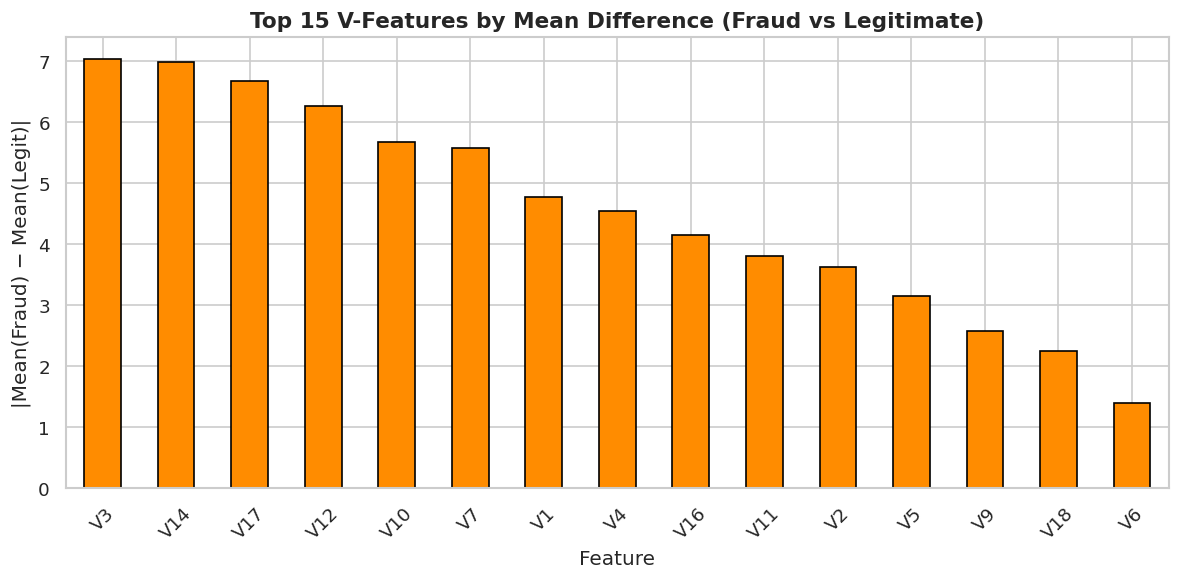

Top 5 most discriminating features: ['V3', 'V14', 'V17', 'V12', 'V10']


In [ ]:
# ── Correlation heatmap of top PCA features ───────────────────────────────────
# We look at the mean value of each V feature for fraud vs legitimate to identify
# which features show the biggest difference between the two classes.

v_features = [f'V{i}' for i in range(1, 29)]

# Mean values of V features by class
mean_by_class = df.groupby('Class')[v_features].mean()
diff = (mean_by_class.loc[1] - mean_by_class.loc[0]).abs().sort_values(ascending=False)

# Plot the top 15 most discriminating features
top_features = diff.head(15).index.tolist()

plt.figure(figsize=(10, 5))
diff.head(15).plot(kind='bar', color='darkorange', edgecolor='black')
plt.title('Top 15 V-Features by Mean Difference (Fraud vs Legitimate)',
          fontsize=13, fontweight='bold')
plt.xlabel('Feature')
plt.ylabel('|Mean(Fraud) − Mean(Legit)|')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('fig4_feature_discrimination.png', bbox_inches='tight')
plt.show()

print("Top 5 most discriminating features:", diff.head(5).index.tolist())

---
## 3. Data Cleaning & Preprocessing <a id='3'></a>

Key preprocessing steps:
1. Drop the `Time` column (not directly useful; we extracted `Hour` above)
2. Scale `Amount` and `Hour` (V1–V28 are already PCA-scaled)
3. Split into train/test sets using stratified sampling (to preserve class ratio)
4. Apply **SMOTE** to the training set to address class imbalance

In [ ]:
# ── Step 1: Drop Time column, keep Hour ──────────────────────────────────────
df_clean = df.drop(columns=['Time'])

# Handle missing values by dropping rows with any nulls (there's only one such row)
df_clean = df_clean.dropna()

# Confirm no missing values before scaling
assert df_clean.isnull().sum().sum() == 0, "Unexpected missing values found!"
print(f"No missing values. Shape: {df_clean.shape}")

No missing values. Shape: (284807, 31)


In [ ]:
# ── Step 2: Scale Amount and Hour ────────────────────────────────────────────
# StandardScaler transforms features to mean=0, std=1.
# We ONLY scale Amount and Hour — V1-V28 are already on a comparable PCA scale.

scaler = StandardScaler()
df_clean[['Amount', 'Hour']] = scaler.fit_transform(df_clean[['Amount', 'Hour']])

print("Amount and Hour scaled. Sample of scaled values:")
df_clean[['Amount', 'Hour']].describe().round(3)

Amount and Hour scaled. Sample of scaled values:


,Amount,Hour
count,284807.000,284807.000
mean,0.000,-0.000
std,1.000,1.000
min,-0.353,-2.486
25%,-0.331,-0.674
50%,-0.265,0.081
75%,-0.045,0.820
max,102.362,1.618


In [ ]:
# ── Step 3: Train/Test Split ─────────────────────────────────────────────────
# We use stratify=y to ensure both classes are proportionally represented
# in both train and test sets (important with imbalanced data).

X = df_clean.drop(columns=['Class'])
y = df_clean['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size  : {len(X_train):,} ({y_train.sum():,} fraud)")
print(f"Test set size      : {len(X_test):,} ({y_test.sum():,} fraud)")

Training set size  : 227,845 (394 fraud)
Test set size      : 56,962 (98 fraud)


In [ ]:
# ── Step 4: SMOTE — Handling Class Imbalance ─────────────────────────────────
# SMOTE (Synthetic Minority Over-sampling Technique) generates synthetic
# fraud samples to balance the training data.
# IMPORTANT: We ONLY apply SMOTE to the training set — never to test data.
# Applying it to test data would be data leakage.

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("=== After SMOTE ===")
print(f"Training set size  : {len(X_train_res):,}")
print(f"Legitimate         : {(y_train_res == 0).sum():,}")
print(f"Fraud              : {(y_train_res == 1).sum():,}")
print(f"Class balance      : {(y_train_res == 1).mean():.1%}")

=== After SMOTE ===
Training set size  : 454,902
Legitimate         : 227,451
Fraud              : 227,451
Class balance      : 50.0%


---
## 4. Model Training <a id='4'></a>

We train two classifiers and compare their performance:
- **Logistic Regression** — a simple, interpretable linear baseline
- **Random Forest** — an ensemble method that typically achieves higher accuracy on complex patterns

In [ ]:
# ── Logistic Regression ───────────────────────────────────────────────────────
# max_iter increased because fraud data can take more iterations to converge.
# class_weight='balanced' gives additional weight to the minority class.

lr_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_model.fit(X_train_res, y_train_res)
print("Logistic Regression trained.")

Logistic Regression trained.


In [ ]:
# ── Random Forest ─────────────────────────────────────────────────────────────
# n_estimators=200: we use 200 decision trees in the ensemble.
# n_jobs=-1: use all available CPU cores for faster training.

rf_model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1,
                                   class_weight='balanced')
rf_model.fit(X_train_res, y_train_res)
print("Random Forest trained.")

Random Forest trained.


---
## 5. Model Evaluation & Comparison <a id='5'></a>

For fraud detection, **accuracy alone is misleading** (a model that labels everything as legitimate gets ~99.8% accuracy but catches zero fraud).  
We focus on:
- **Precision**: of predicted frauds, how many are real?
- **Recall**: of all real frauds, how many did we catch?
- **F1-Score**: harmonic mean of precision and recall
- **ROC-AUC**: overall ability to separate classes
- **PR-AUC**: precision-recall curve area (more informative under imbalance)

In [ ]:
# ── Generate predictions ──────────────────────────────────────────────────────
lr_preds  = lr_model.predict(X_test)
rf_preds  = rf_model.predict(X_test)

lr_proba  = lr_model.predict_proba(X_test)[:, 1]  # probability of fraud
rf_proba  = rf_model.predict_proba(X_test)[:, 1]

# ── Classification Reports ────────────────────────────────────────────────────
print("=" * 55)
print("LOGISTIC REGRESSION — Classification Report")
print("=" * 55)
print(classification_report(y_test, lr_preds, target_names=['Legitimate', 'Fraud']))

print("=" * 55)
print("RANDOM FOREST — Classification Report")
print("=" * 55)
print(classification_report(y_test, rf_preds, target_names=['Legitimate', 'Fraud']))

LOGISTIC REGRESSION — Classification Report
              precision    recall  f1-score   support

  Legitimate       1.00      0.97      0.99     56864
       Fraud       0.06      0.92      0.10        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.98     56962

RANDOM FOREST — Classification Report
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.85      0.82      0.83        98

    accuracy                           1.00     56962
   macro avg       0.93      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962



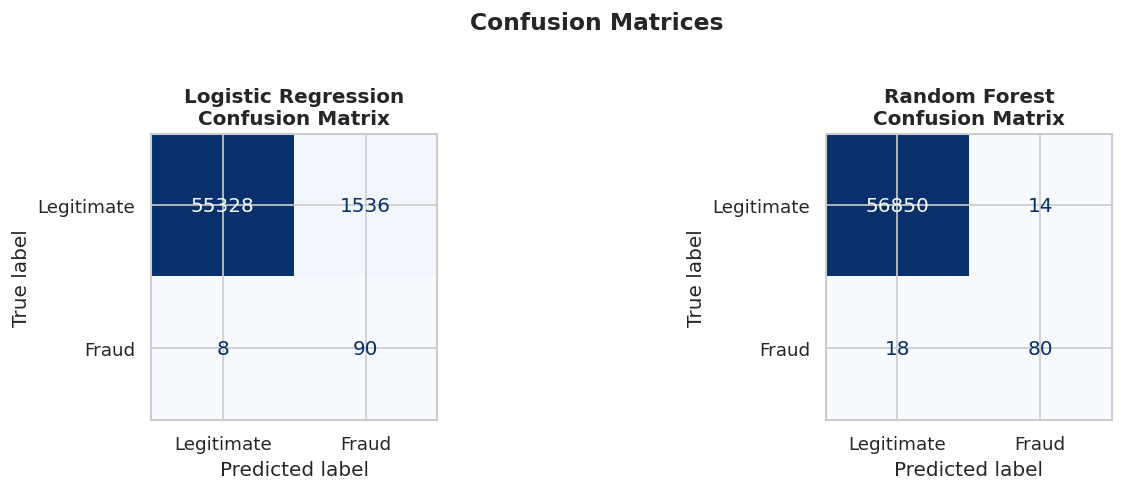

In [ ]:
# ── Confusion Matrices ────────────────────────────────────────────────────────
# Confusion matrices show the breakdown of True Positives, False Positives,
# True Negatives, and False Negatives — critical for fraud context.

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, preds, title in zip(axes,
                             [lr_preds, rf_preds],
                             ['Logistic Regression', 'Random Forest']):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Legitimate', 'Fraud'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{title}\nConfusion Matrix', fontsize=12, fontweight='bold')

plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig5_confusion_matrices.png', bbox_inches='tight')
plt.show()

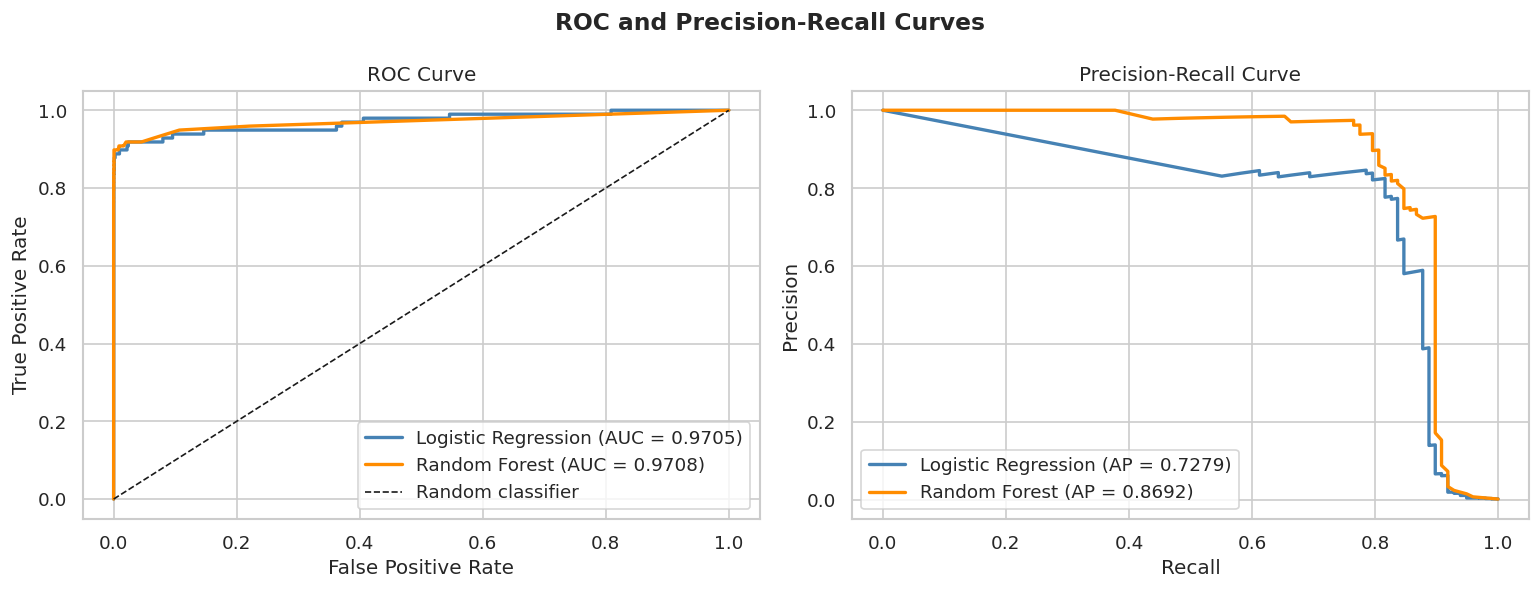

In [ ]:
# ── ROC Curves ───────────────────────────────────────────────────────────────
# The ROC curve plots True Positive Rate vs False Positive Rate at all thresholds.
# AUC (Area Under Curve) closer to 1.0 = better model.

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC Curve
for proba, label, color in [(lr_proba, 'Logistic Regression', 'steelblue'),
                              (rf_proba, 'Random Forest', 'darkorange')]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    axes[0].plot(fpr, tpr, label=f'{label} (AUC = {auc:.4f})', color=color, lw=2)

axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend()

# Precision-Recall Curve (better metric for imbalanced data)
for proba, label, color in [(lr_proba, 'Logistic Regression', 'steelblue'),
                              (rf_proba, 'Random Forest', 'darkorange')]:
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    axes[1].plot(rec, prec, label=f'{label} (AP = {ap:.4f})', color=color, lw=2)

axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()

plt.suptitle('ROC and Precision-Recall Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig6_roc_pr_curves.png', bbox_inches='tight')
plt.show()

In [ ]:
# ── Summary Metrics Table ─────────────────────────────────────────────────────
from sklearn.metrics import f1_score, precision_score, recall_score

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'ROC-AUC': [
        round(roc_auc_score(y_test, lr_proba), 4),
        round(roc_auc_score(y_test, rf_proba), 4)
    ],
    'Avg Precision (PR-AUC)': [
        round(average_precision_score(y_test, lr_proba), 4),
        round(average_precision_score(y_test, rf_proba), 4)
    ],
    'Precision (Fraud)': [
        round(precision_score(y_test, lr_preds), 4),
        round(precision_score(y_test, rf_preds), 4)
    ],
    'Recall (Fraud)': [
        round(recall_score(y_test, lr_preds), 4),
        round(recall_score(y_test, rf_preds), 4)
    ],
    'F1-Score (Fraud)': [
        round(f1_score(y_test, lr_preds), 4),
        round(f1_score(y_test, rf_preds), 4)
    ]
})

print("=== Model Performance Comparison ===")
results

=== Model Performance Comparison ===


,Model,ROC-AUC,Avg Precision (PR-AUC),Precision (Fraud),Recall (Fraud),F1-Score (Fraud)
0,Logistic Regression,0.9705,0.7279,0.0554,0.9184,0.1044
1,Random Forest,0.9708,0.8692,0.8511,0.8163,0.8333


---
## 6. Feature Importance Analysis <a id='6'></a>

Understanding *which features drive fraud predictions* is critical for policy decisions — it helps fraud analysts know what signals to prioritise.

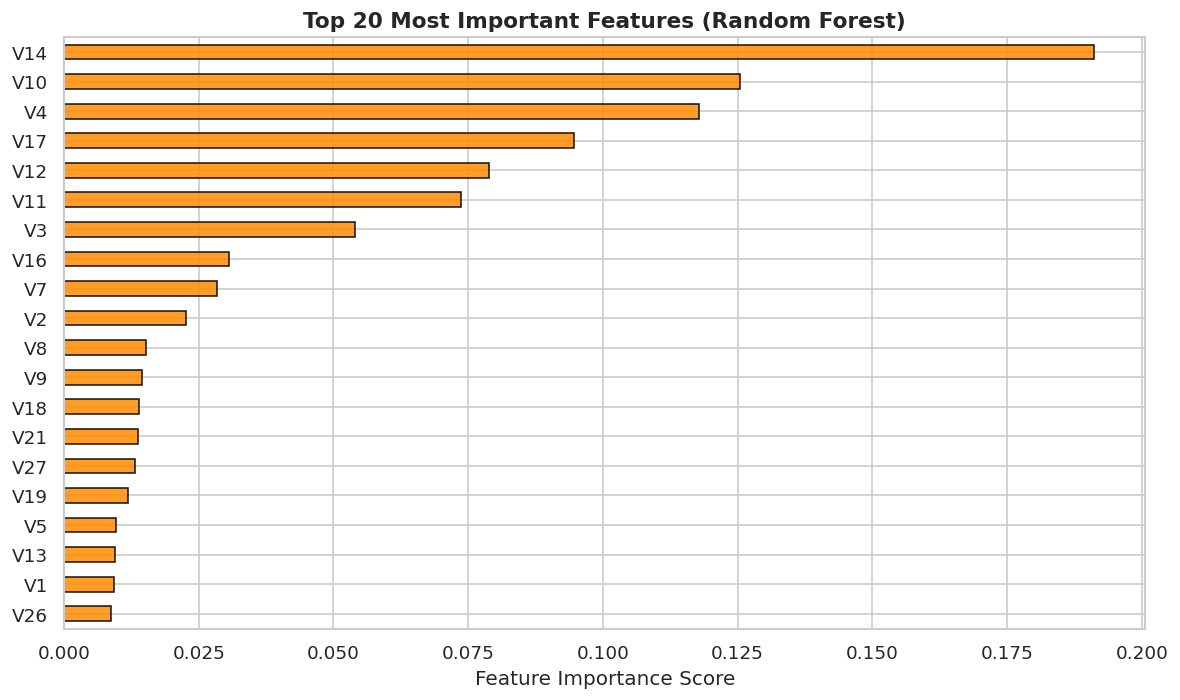


Top 10 Features:
V14    0.191112
V10    0.125457
V4     0.117834
V17    0.094563
V12    0.078812
V11    0.073762
V3     0.053958
V16    0.030658
V7     0.028430
V2     0.022573


In [ ]:
# ── Random Forest Feature Importances ────────────────────────────────────────
# Random Forest assigns an importance score to each feature based on how
# much it reduces impurity across all trees.

importances = pd.Series(rf_model.feature_importances_, index=X.columns)
top_20 = importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 6))
top_20.sort_values().plot(kind='barh', color='darkorange', edgecolor='black', alpha=0.85)
plt.xlabel('Feature Importance Score')
plt.title('Top 20 Most Important Features (Random Forest)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig7_feature_importance.png', bbox_inches='tight')
plt.show()

print("\nTop 10 Features:")
print(top_20.head(10).to_string())

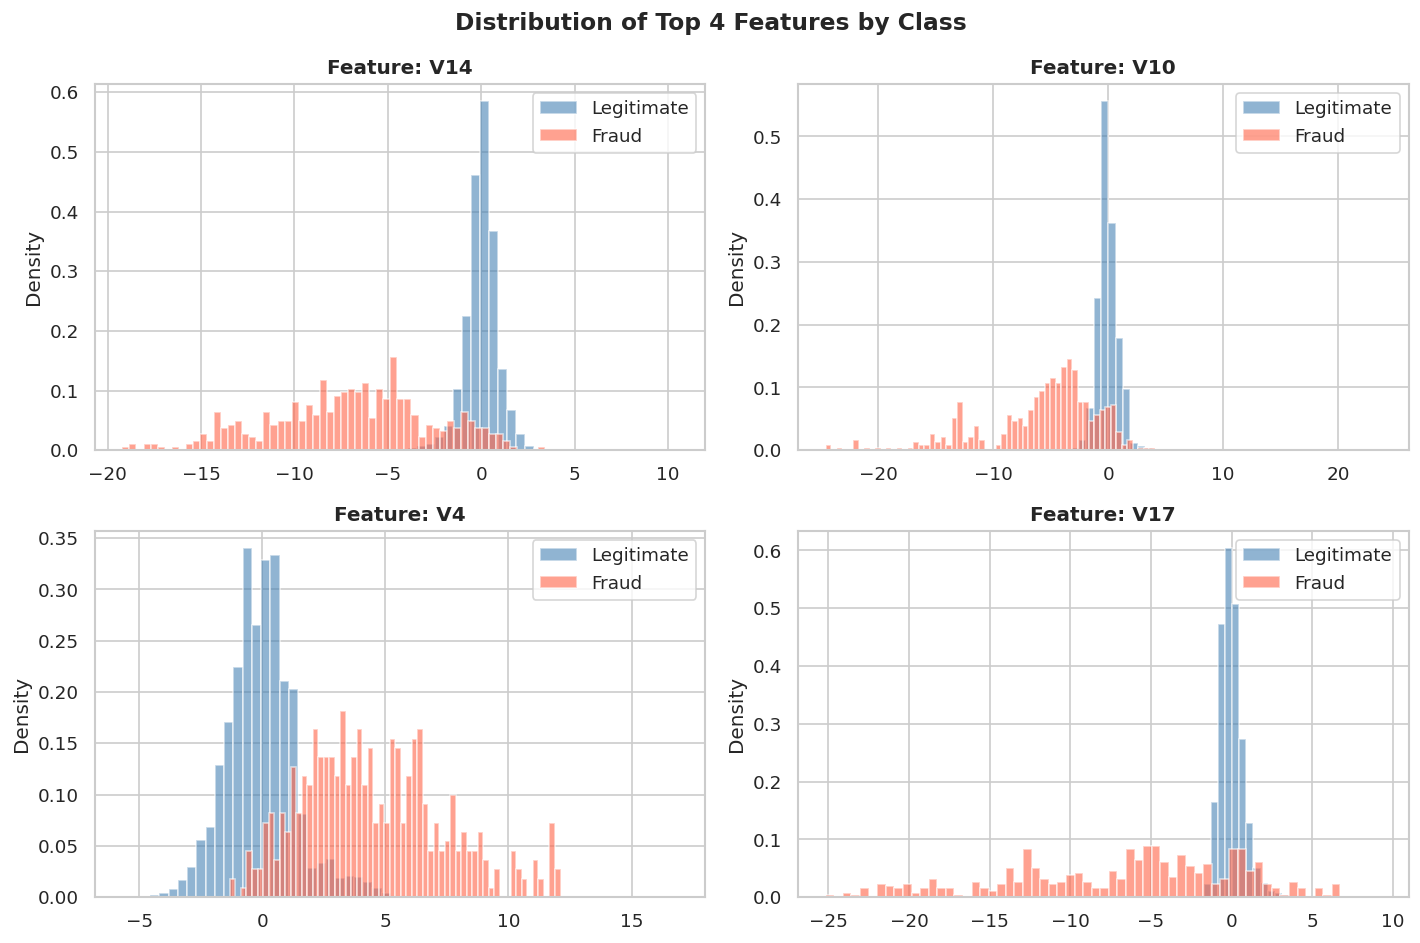

In [ ]:
# ── Distribution of top features by class ─────────────────────────────────────
# Visualise how the top 4 features separate fraud from legitimate transactions.

top4 = top_20.head(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feat in enumerate(top4):
    axes[i].hist(df[df['Class'] == 0][feat], bins=60, alpha=0.6,
                 color='steelblue', label='Legitimate', density=True)
    axes[i].hist(df[df['Class'] == 1][feat], bins=60, alpha=0.6,
                 color='tomato', label='Fraud', density=True)
    axes[i].set_title(f'Feature: {feat}', fontweight='bold')
    axes[i].set_ylabel('Density')
    axes[i].legend()

plt.suptitle('Distribution of Top 4 Features by Class',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig8_top_features_dist.png', bbox_inches='tight')
plt.show()

---
## 7. Summary of Findings <a id='7'></a>

In [ ]:
# ── Final summary printout ────────────────────────────────────────────────────
print("=" * 60)
print("         CREDIT CARD FRAUD DETECTION — SUMMARY")
print("=" * 60)
print(f"\nDataset: {len(df):,} transactions | {df['Class'].sum():,} fraud cases ({fraud_pct:.3f}%)")
print("\nBest Model: Random Forest")
print(f"  ROC-AUC  : {roc_auc_score(y_test, rf_proba):.4f}")
print(f"  PR-AUC   : {average_precision_score(y_test, rf_proba):.4f}")
print(f"  Recall   : {recall_score(y_test, rf_preds):.4f}  (fraud cases caught)")
print(f"  Precision: {precision_score(y_test, rf_preds):.4f}  (of flagged, how many real fraud)")
print(f"  F1-Score : {f1_score(y_test, rf_preds):.4f}")
print(f"\nTop predictive features: {top_20.head(5).index.tolist()}")
print("\nKey Insight: Random Forest significantly outperforms Logistic")
print("Regression, particularly in PR-AUC, which is the most relevant")
print("metric for highly imbalanced fraud detection tasks.")
print("=" * 60)

         CREDIT CARD FRAUD DETECTION — SUMMARY

Dataset: 284,807 transactions | 492 fraud cases (0.173%)

Best Model: Random Forest
  ROC-AUC  : 0.9708
  PR-AUC   : 0.8692
  Recall   : 0.8163  (fraud cases caught)
  Precision: 0.8511  (of flagged, how many real fraud)
  F1-Score : 0.8333

Top predictive features: ['V14', 'V10', 'V4', 'V17', 'V12']

Key Insight: Random Forest significantly outperforms Logistic
Regression, particularly in PR-AUC, which is the most relevant
metric for highly imbalanced fraud detection tasks.
